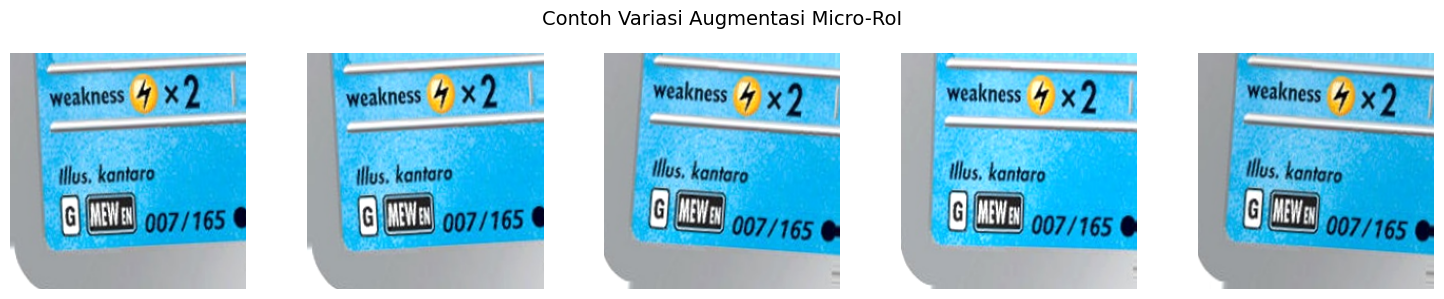

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from pathlib import Path

# 1. Konfigurasi Augmentasi (Sesuai parameter Bab 3)
datagen = ImageDataGenerator(
    rotation_range=5,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# 2. Muat SATU gambar Micro-RoI yang sudah dipotong (crop)
# Ganti path ini dengan lokasi gambar kartu apa saja yang sudah di-crop
img_path = Path("..") / "data" / "patches (70-15-15)" / "test" / "151" / "sv3-5_en_007_std.jpg"

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # Ubah matriks menjadi format batch (1, 224, 224, 3)

# 3. Hasilkan dan tampilkan 5 contoh variasi gambar
plt.figure(figsize=(15, 3))
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(1, 5, i+1)
    # Konversi float kembali ke uint8 untuk keperluan visualisasi
    plt.imshow(batch[0].astype('uint8')) 
    plt.axis('off')
    i += 1
    if i % 5 == 0: # Hentikan perulangan setelah 5 gambar terbentuk
        break

plt.suptitle('Contoh Variasi Augmentasi Micro-RoI', fontsize=14)
plt.tight_layout()
plt.show()